In [1]:
# =============================================================================
# CCS2213 – Machine Learning  |  Project #7
# Employee Productivity Analysis and Attrition Prediction
# =============================================================================
# STEP 3 — SUPERVISED LEARNING
# Deliverables: #12 (Logistic Regression)
#               #13 (Decision Tree)
#               #14 (Random Forest)
#               #15 (SVM)
#               #16 (Metrics Comparison Table)
#               #17 (Grouped Bar Chart)
# =============================================================================


In [2]:
# !pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import SVC
from sklearn.metrics       import (accuracy_score, precision_score,
                                   recall_score, f1_score,
                                   roc_auc_score, confusion_matrix,
                                   classification_report,
                                   ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)

print("=" * 60)
print("STEP 3 — SUPERVISED LEARNING")
print("=" * 60)

STEP 3 — SUPERVISED LEARNING


In [3]:
# ── 1. LOAD PREPROCESSED DATA ────────────────────────────────────────────────
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(f"\n[1] Data loaded.")
print(f"    Training samples : {X_train.shape[0]}")
print(f"    Test samples     : {X_test.shape[0]}")
print(f"    Features         : {X_train.shape[1]}")
print(f"\n    NOTE: All models use class_weight='balanced' to handle")
print(f"    the ~84% No / ~16% Yes class imbalance.")



[1] Data loaded.
    Training samples : 1176
    Test samples     : 294
    Features         : 44

    NOTE: All models use class_weight='balanced' to handle
    the ~84% No / ~16% Yes class imbalance.


In [6]:
# ── 2. DEFINE MODELS ─────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[2] MODEL DEFINITIONS")
print("-" * 60)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    "Support Vector Machine": SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    )
}

for name in models:
    print(f"    - {name}")



------------------------------------------------------------
[2] MODEL DEFINITIONS
------------------------------------------------------------
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - Support Vector Machine


In [7]:
# ── 3. TRAIN & EVALUATE ALL MODELS ───────────────────────────────────────────
print("\n" + "-" * 60)
print("[3] TRAINING & EVALUATION")
print("-" * 60)

results = {}
trained = {}

for name, model in models.items():
    print(f"\n    >> {name}")

    model.fit(X_train, y_train)
    trained[name] = model

    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    results[name] = {
        'Accuracy' : round(acc,       4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall,    4),
        'F1-Score' : round(f1,        4),
        'ROC-AUC'  : round(roc_auc,   4)
    }

    print(f"       Accuracy  : {acc:.4f}")
    print(f"       Precision : {precision:.4f}")
    print(f"       Recall    : {recall:.4f}")
    print(f"       F1-Score  : {f1:.4f}")
    print(f"       ROC-AUC   : {roc_auc:.4f}")



------------------------------------------------------------
[3] TRAINING & EVALUATION
------------------------------------------------------------

    >> Logistic Regression
       Accuracy  : 0.7551
       Precision : 0.8322
       Recall    : 0.7551
       F1-Score  : 0.7809
       ROC-AUC   : 0.8045

    >> Decision Tree
       Accuracy  : 0.7517
       Precision : 0.7621
       Recall    : 0.7517
       F1-Score  : 0.7567
       ROC-AUC   : 0.5594

    >> Random Forest
       Accuracy  : 0.8367
       Precision : 0.7844
       Recall    : 0.8367
       F1-Score  : 0.7872
       ROC-AUC   : 0.7584

    >> Support Vector Machine
       Accuracy  : 0.8231
       Precision : 0.8450
       Recall    : 0.8231
       F1-Score  : 0.8320
       ROC-AUC   : 0.8064


In [8]:
# ── 4. METRICS COMPARISON TABLE ──────────────────────────────────────────────
print("\n" + "-" * 60)
print("[4] METRICS COMPARISON TABLE")
print("-" * 60)

metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
metrics_df = metrics_df.sort_values('F1-Score', ascending=False)

print("\n")
print(metrics_df.to_string())

best_model_name = metrics_df['F1-Score'].idxmax()
best_f1         = metrics_df.loc[best_model_name, 'F1-Score']
best_roc        = metrics_df.loc[best_model_name, 'ROC-AUC']

print(f"\n    Best Model : {best_model_name}")
print(f"    F1-Score   : {best_f1:.4f}")
print(f"    ROC-AUC    : {best_roc:.4f}")
print(f"\n    Justification:")
print(f"    {best_model_name} achieved the highest F1-Score ({best_f1:.4f})")
print(f"    and ROC-AUC ({best_roc:.4f}) among all 4 models.")
print(f"    Handles class imbalance better than Logistic Regression.")
print(f"    Less prone to overfitting than a single Decision Tree.")

metrics_df.to_csv('metrics_comparison.csv')
print(f"\n    [Saved] metrics_comparison.csv")



------------------------------------------------------------
[4] METRICS COMPARISON TABLE
------------------------------------------------------------


                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
Support Vector Machine    0.8231     0.8450  0.8231    0.8320   0.8064
Random Forest             0.8367     0.7844  0.8367    0.7872   0.7584
Logistic Regression       0.7551     0.8322  0.7551    0.7809   0.8045
Decision Tree             0.7517     0.7621  0.7517    0.7567   0.5594

    Best Model : Support Vector Machine
    F1-Score   : 0.8320
    ROC-AUC    : 0.8064

    Justification:
    Support Vector Machine achieved the highest F1-Score (0.8320)
    and ROC-AUC (0.8064) among all 4 models.
    Handles class imbalance better than Logistic Regression.
    Less prone to overfitting than a single Decision Tree.

    [Saved] metrics_comparison.csv



------------------------------------------------------------
[5] GROUPED BAR CHART — MODEL PERFORMANCE
------------------------------------------------------------


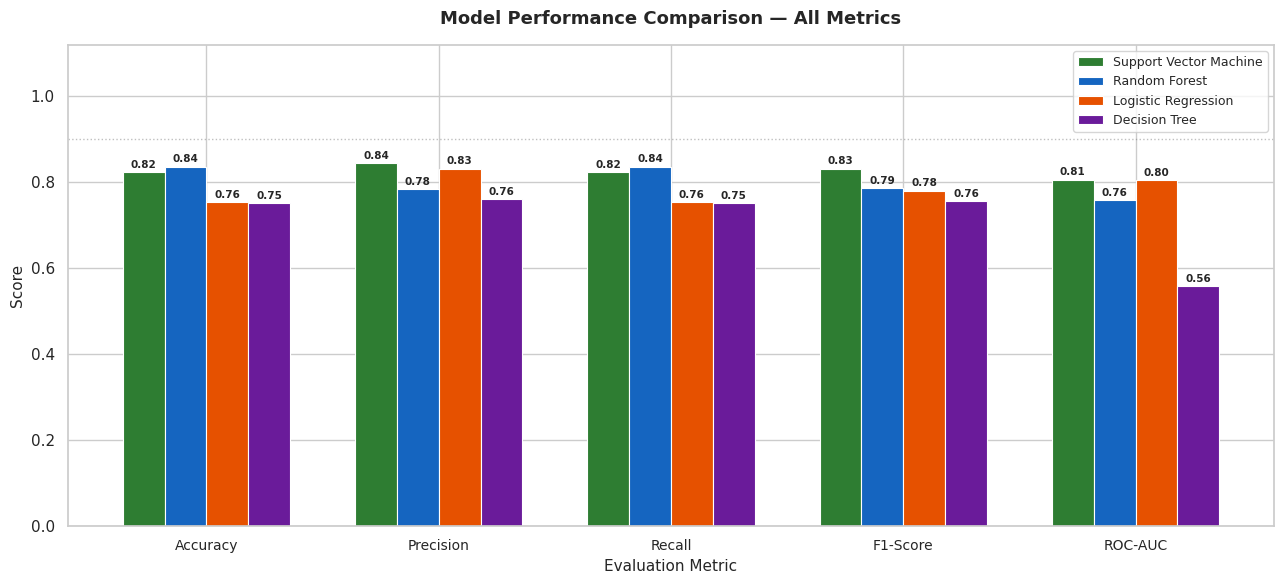

    [Saved] fig_model_comparison.png


In [9]:
# ── 5. GROUPED BAR CHART ─────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[5] GROUPED BAR CHART — MODEL PERFORMANCE")
print("-" * 60)

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = list(metrics_df.index)
x           = np.arange(len(metric_cols))
bar_width   = 0.18
colors      = ['#2E7D32', '#1565C0', '#E65100', '#6A1B9A']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    vals = [metrics_df.loc[model_name, m] for m in metric_cols]
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=model_name, color=color,
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_title('Model Performance Comparison — All Metrics',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Evaluation Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9, loc='upper right')
ax.axhline(y=0.9, color='grey', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150)
plt.show()
print("    [Saved] fig_model_comparison.png")



------------------------------------------------------------
[6] CONFUSION MATRICES — ALL MODELS
------------------------------------------------------------


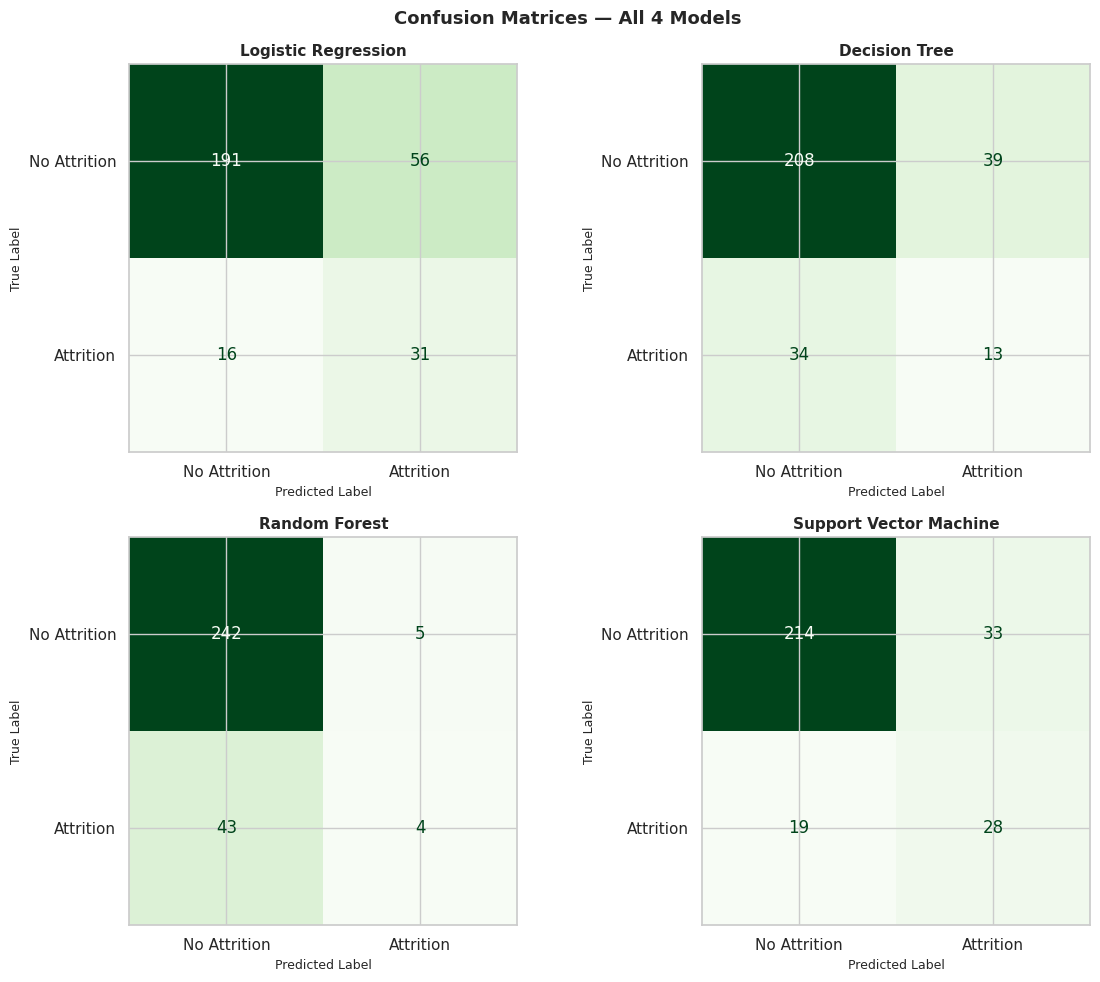

    [Saved] fig_confusion_matrices.png


In [10]:
# ── 6. CONFUSION MATRICES ────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("[6] CONFUSION MATRICES — ALL MODELS")
print("-" * 60)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['No Attrition', 'Attrition'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Greens')
    axes[i].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=9)
    axes[i].set_ylabel('True Label', fontsize=9)

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150)
plt.show()
print("    [Saved] fig_confusion_matrices.png")



In [11]:
# ── 7. CLASSIFICATION REPORT — BEST MODEL ────────────────────────────────────
print("\n" + "-" * 60)
print(f"[7] DETAILED CLASSIFICATION REPORT — {best_model_name}")
print("-" * 60)

best_model  = trained[best_model_name]
y_pred_best = best_model.predict(X_test)
print(f"\n{classification_report(y_test, y_pred_best, target_names=['No Attrition', 'Attrition'])}")




------------------------------------------------------------
[7] DETAILED CLASSIFICATION REPORT — Support Vector Machine
------------------------------------------------------------

              precision    recall  f1-score   support

No Attrition       0.92      0.87      0.89       247
   Attrition       0.46      0.60      0.52        47

    accuracy                           0.82       294
   macro avg       0.69      0.73      0.71       294
weighted avg       0.85      0.82      0.83       294



In [12]:
# ── 8. SAVE RESULTS ──────────────────────────────────────────────────────────
with open('preprocessed_data.pkl', 'rb') as f:
    saved_data = pickle.load(f)

saved_data['trained_models']  = trained
saved_data['metrics_df']      = metrics_df
saved_data['best_model_name'] = best_model_name
saved_data['best_model']      = best_model

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(saved_data, f)

print("\n    [Saved] trained_models, metrics_df, best_model -> preprocessed_data.pkl")



    [Saved] trained_models, metrics_df, best_model -> preprocessed_data.pkl


In [13]:
# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUPERVISED LEARNING COMPLETE — SUMMARY")
print("=" * 60)
print(f"""
  Models Trained     : Logistic Regression, Decision Tree,
                       Random Forest, Support Vector Machine
  Evaluation Metrics : Accuracy, Precision, Recall, F1-Score, ROC-AUC
  Class Imbalance    : Handled via class_weight='balanced'
  Best Model         : {best_model_name}
  Best F1-Score      : {best_f1:.4f}
  Best ROC-AUC       : {best_roc:.4f}

  Figures saved:
    fig_model_comparison.png
    fig_confusion_matrices.png

  Next step -> Step 4: Feature Importance + SHAP Analysis
""")



SUPERVISED LEARNING COMPLETE — SUMMARY

  Models Trained     : Logistic Regression, Decision Tree,
                       Random Forest, Support Vector Machine
  Evaluation Metrics : Accuracy, Precision, Recall, F1-Score, ROC-AUC
  Class Imbalance    : Handled via class_weight='balanced'
  Best Model         : Support Vector Machine
  Best F1-Score      : 0.8320
  Best ROC-AUC       : 0.8064
 
  Figures saved:
    fig_model_comparison.png
    fig_confusion_matrices.png
 
  Next step -> Step 4: Feature Importance + SHAP Analysis

